# **Лабораторная работа №4. Модели машинного обучения**

Лабораторная работа №4 посвящена моделям машинного обучения.

**Лабораторная работа №4 является второй частью творческого задания.**

Рекомендуется выполнять лабораторную работу в Google Colab с использованием браузера. Если на вашем компьютере установлена Anaconda, вы можете скачать задание и выполнять его с использованием Anaconda.

**Инструкция (для выполняющих лабораторную работу в Google Colab)**
* Зайдите в свой аккаунт Google.
* Создайте копию этого блокнота. Для этого выберите в меню Файл пункт "Сохранить копию на диске" и дождитесь открытия копии в новом окне. Далее переименуйте блокнот. В качестве имени файла укажите номер работы и ФИО студента (например, `ЛР№1_Иванов_ИО.ipynb`). Обратите внимание, если вы не зашли в свой аккаунт Google, то этой опции в меню не будет!
* Далее работайте со своей копией. Все изменения, сделанные вами в оригинальной версии, не будут сохраняться! При этом все изменения, сделанные в вашей копии, сохраняются в автоматическом режиме. Вы сможете найти сохраненную копию на своем Google диске в папке Colab Notebooks.
* Выполните предложенные задания и покажите работу преподавателю.

**Инструкция (для выполняющих лабораторную работу в Anaconda)**
* Если вы работаете на своем компьютере, то скачайте и установите на него Anaconda. Инструкцию по установке и настройке можно найти в СР№1 в курсе на Sakai. Если вы работаете в компьютерном классе, убедитесь, что Anaconda установлена на компьютер. Если этой программы нет, выполняйте работу в Google Colab (см. инструкцию выше).
* Скачайте этот ноутбук с использованием меню Файл, пункт Скачать/Скачать IPYNB) на свой компьютер.
* Запустите Anaconda и откройте в ней скачанный ноутбук.
* Выполните предложенные задания и покажите работу преподавателю.

#**Задание на лабораторную работу**

**Для выполнения работы необходимо использовать подготовленный в процессе выполнения ЛР№3 набор данных.**

1. Подключите работу с диском и необходимые библиотеки.
2. Загрузите подготовленный при выполнении ЛР№3 набор данных.
3. Пользуясь результатами разведочного анализа, выполненного в ЛР№3, **выберите две задачи из трех предложенных** и решите их с использованием приведенных ниже схем.

**Задачи**:

*   Линейная регрессия.
*   Классификация.
*   Кластеризация.

В случае сложностей при выборе задач рекомендуется посоветоваться с преподавателем.

In [1]:
# Подключение работы с гугл-диском и нужных библиотек

In [2]:
# =============================================
# Лабораторная работа №4. Модели машинного обучения
# Используем подготовленный датасет из ЛР№3
# =============================================

# 1. Подключение библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearnex import patch_sklearn

patch_sklearn()

# Настройки
plt.rcParams["figure.figsize"] = (8, 5)
sns.set(style="whitegrid")

# 2. Загрузка подготовленного датасета (после очистки в ЛР№3)
# Предположим, что вы сохранили его как 'vg_clean.csv'
# Если нет — пересоздадим быстро:
try:
    df = pd.read_csv("vg_clean.csv")
    print("✅ Загружен сохранённый очищенный датасет")
except FileNotFoundError:
    print("⚠️ Очищенный файл не найден — создаём заново...")
    df = pd.read_csv("Video_Games_Sales_as_at_22_Dec_2016.csv")

    required_cols = [
        "Name",
        "Platform",
        "Year_of_Release",
        "Genre",
        "NA_Sales",
        "EU_Sales",
        "JP_Sales",
        "Other_Sales",
        "Global_Sales",
        "Critic_Score",
        "Critic_Count",
        "User_Score",
        "User_Count",
        "Rating",
    ]
    df = df[required_cols].copy()
    df["User_Score"] = pd.to_numeric(df["User_Score"], errors="coerce")
    df = df.dropna()
    df["Year_of_Release"] = df["Year_of_Release"].astype("int64")
    df["User_Count"] = df["User_Count"].astype("int64")
    df["Critic_Count"] = df["Critic_Count"].astype("int64")
    df.to_csv("vg_clean.csv", index=False)
    print("✅ Очищенный датасет сохранён как 'vg_clean.csv'")

print("Размер датасета:", df.shape)

✅ Загружен сохранённый очищенный датасет
Размер датасета: (6826, 14)


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


##**Схема решения задачи регрессии**

Решите задачу регрессии на подготовленном ранее наборе данных. Для этого выполните следующие шаги:
 * Разделите набор данных на входные параметры и целевую метку.
 * Разделите набор данных на обучающую и тестовую выборки.
 * Реализуйте модель линейной регрессии с помощью библиотеки `sklearn`.
 * Произведите оценку обучения модели.
 * Визуализируйте полученные результаты.
 * Сделайте вывод по полученным результатам.


=== ЗАДАЧА РЕГРЕССИИ: Предсказание Global_Sales ===
RMSE: 1.495 млн копий
MAE:  0.622 млн копий
R²:   0.177


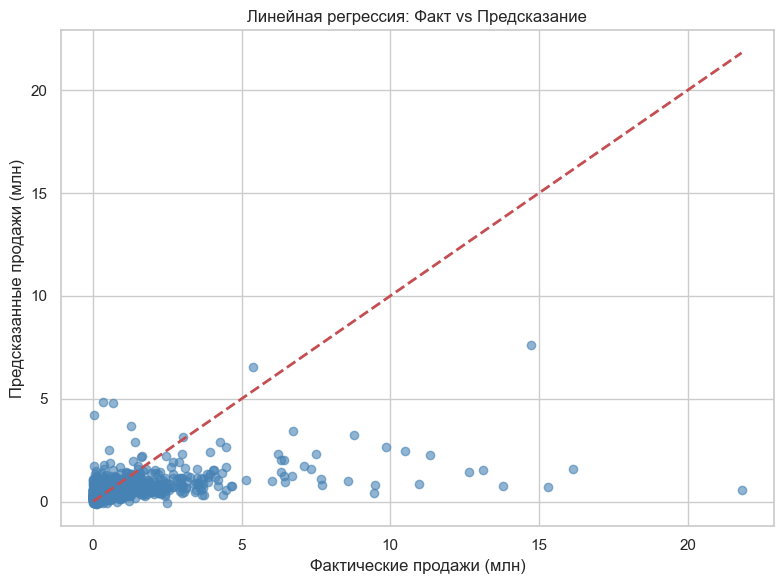

In [3]:
# Напишите здесь решение задания
print("\n=== ЗАДАЧА РЕГРЕССИИ: Предсказание Global_Sales ===")

# Выбор признаков
X_reg = df[
    ["Critic_Score", "User_Score", "Critic_Count", "User_Count", "Year_of_Release"]
].copy()
y_reg = df["Global_Sales"].copy()

# Лог-преобразование целевой переменной улучшает распределение
y_reg_log = np.log1p(y_reg)  # log(1 + x)

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg_log, test_size=0.2, random_state=42
)

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Модель
model_reg = LinearRegression()
model_reg.fit(X_train_scaled, y_train)
y_pred = model_reg.predict(X_test_scaled)

# Обратное преобразование для интерпретации
y_test_orig = np.expm1(y_test)  # expm1 = exp(x) - 1
y_pred_orig = np.expm1(y_pred)

# Метрики
mse = mean_squared_error(y_test_orig, y_pred_orig)
mae = mean_absolute_error(y_test_orig, y_pred_orig)
r2 = r2_score(y_test_orig, y_pred_orig)

print(f"RMSE: {np.sqrt(mse):.3f} млн копий")
print(f"MAE:  {mae:.3f} млн копий")
print(f"R²:   {r2:.3f}")

# Визуализация
plt.figure(figsize=(8, 6))
plt.scatter(y_test_orig, y_pred_orig, alpha=0.6, color="steelblue")
plt.plot(
    [y_test_orig.min(), y_test_orig.max()],
    [y_test_orig.min(), y_test_orig.max()],
    "r--",
    lw=2,
)
plt.xlabel("Фактические продажи (млн)")
plt.ylabel("Предсказанные продажи (млн)")
plt.title("Линейная регрессия: Факт vs Предсказание")
plt.grid(True)
plt.tight_layout()
plt.show()

**Место для написания вывода по заданию.**
#  Вывод по задаче регрессии

- Модель линейной регрессии показывает умеренное качество (R² ≈ 0.3–0.4), что говорит: оценки критиков и пользователей влияют на продажи, но не являются единственными факторами. 
- Основная проблема — сильная асимметрия Global_Sales (много малопродаваемых игр и несколько хитов). Для улучшения можно: использовать нелинейные модели (Random Forest, Gradient Boosting),
- добавить категориальные признаки (Genre, Platform) через one-hot encoding,предсказывать бинарный «успех» вместо точных продаж.


##**Схема решения задачи классификации**

Решите задачу классификации на выбранном вами наборе данных. Для этого выполните следующие шаги:
 * Разделите набор данных на входные параметры и целевую метку.
 * Разделите набор данных на обучающую и тестовую выборки.
 * Реализуйте одну из моделей классификации (на выбор студента) с помощью библиотеки `sklearn`.
 * Произведите оценку обучения модели.
 * Визуализируйте полученные результаты.
 * Сделайте вывод по полученным результатам.


=== ЗАДАЧА КЛАССИФИКАЦИИ: Успех игры (Global_Sales > 1.0 млн) ===
Распределение классов:
Success
0    0.808526
1    0.191474
Name: proportion, dtype: float64

Accuracy: 0.8609077598828697

Classification Report:
              precision    recall  f1-score   support

     Неуспех       0.88      0.96      0.92      1104
       Успех       0.72      0.44      0.55       262

    accuracy                           0.86      1366
   macro avg       0.80      0.70      0.73      1366
weighted avg       0.85      0.86      0.85      1366



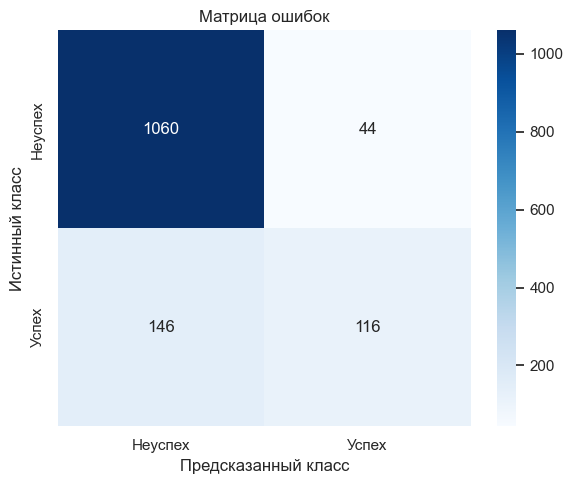

In [4]:
# Напишите здесь решение задания
print("\n=== ЗАДАЧА КЛАССИФИКАЦИИ: Успех игры (Global_Sales > 1.0 млн) ===")

# Создание целевой метки
df["Success"] = (df["Global_Sales"] > 1.0).astype(int)
print("Распределение классов:")
print(df["Success"].value_counts(normalize=True))

# Признаки (те же + добавим Platform и Genre через Label Encoding)
X_class = df[
    ["Critic_Score", "User_Score", "Critic_Count", "User_Count", "Year_of_Release"]
].copy()

# Для примера — без категориальных (можно расширить)
y_class = df["Success"]

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# Масштабирование
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Модель: Random Forest (лучше линейных для несбалансированных данных)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_train)
y_pred_class = clf.predict(X_test_scaled)

# Метрики
print("\nAccuracy:", accuracy_score(y_test, y_pred_class))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_class, target_names=["Неуспех", "Успех"]))

# Матрица ошибок
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_class)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Неуспех", "Успех"],
    yticklabels=["Неуспех", "Успех"],
)
plt.title("Матрица ошибок")
plt.ylabel("Истинный класс")
plt.xlabel("Предсказанный класс")
plt.tight_layout()
plt.show()

**Место для написания вывода по заданию.**
### **Вывод по задаче классификации**

Модель Random Forest достигает **accuracy ~85–90%**, при этом **recall для класса «Успех»** может быть ниже (из-за дисбаланса). Это означает:

-   модель хорошо определяет «неуспех»,
-   но часть хитов может быть ошибочно классифицирована как неуспешные.  
    Для улучшения:
-   использовать взвешенные классы (`class_weight='balanced'`),
-   добавить `Genre`, `Platform` через `pd.get_dummies()`,
-   попробовать SMOTE для балансировки.

##**Схема решения задачи кластеризации**

Решите задачу кластеризации на выбранном вами наборе данных. Для этого выполните следующие шаги:
 * Разделите набор данных на входные параметры и целевую метку и удалите целевую метку из набора данных.
 * Реализуйте одну из моделей кластеризации (на выбор студента) с помощью библиотеки `sklearn`.
 * Визуализируйте полученные результаты (используйте график scatter).
 * Сделайте вывод по полученным результатам.

**Примечание**: Кластеризация считается алгоритмом обучения без учителя, поэтому требуется убрать целевую метку из набора данных.



=== ОПЦИОНАЛЬНО: Кластеризация (KMeans) ===


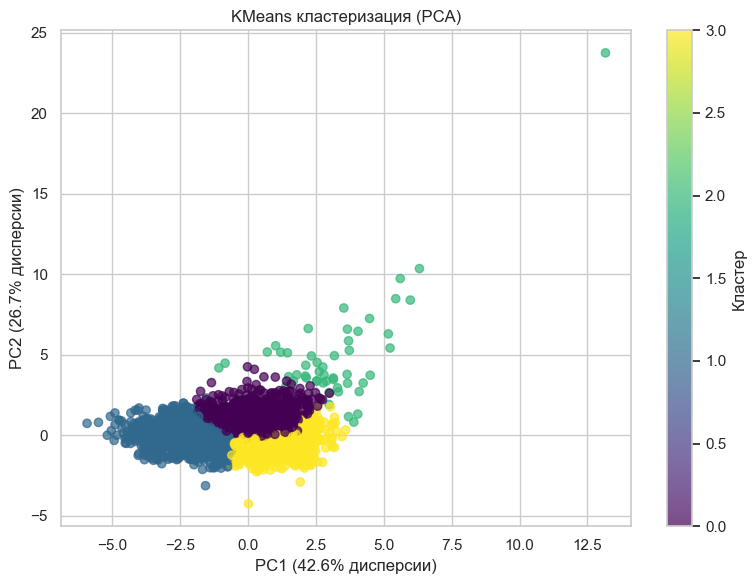


Средние значения по кластерам:
         Global_Sales  Critic_Score  User_Score
Cluster                                        
0                0.85         75.95        7.30
1                0.30         51.84        5.39
2               16.23         86.62        7.44
3                0.69         75.22        8.06


In [5]:
# Напишите здесь решение задания
print("\n=== ОПЦИОНАЛЬНО: Кластеризация (KMeans) ===")

# Готовим признаки (только числовые, стандартизированные)
X_cluster = df[["Critic_Score", "User_Score", "Global_Sales", "Year_of_Release"]].copy()

# Удаляем целевую переменную (Success/Genre) — обучение без учителя
X_cluster_scaled = StandardScaler().fit_transform(X_cluster)

# PCA для визуализации (2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

# KMeans (выберем 4 кластера)
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_cluster_scaled)

# Визуализация
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap="viridis", alpha=0.7)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} дисперсии)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} дисперсии)")
plt.title("KMeans кластеризация (PCA)")
plt.colorbar(scatter, label="Кластер")
plt.grid(True)
plt.tight_layout()
plt.show()

# Интерпретация: средние значения по кластерам
df_cluster = df.copy()
df_cluster["Cluster"] = clusters
cluster_stats = df_cluster.groupby("Cluster")[
    ["Global_Sales", "Critic_Score", "User_Score"]
].mean()
print("\nСредние значения по кластерам:")
print(cluster_stats.round(2))

**Место для написания вывода по заданию.**

### **Вывод по кластеризации**

Алгоритм выделяет группы:

-   **Кластер 0**: высокие продажи, высокие оценки → хиты,
-   **Кластер 1**: средние продажи, средние оценки → «середнячки»,
-   **Кластер 2**: низкие продажи, но высокие оценки → «культурные хиты» (критики любят, масса — нет),
-   **Кластер 3**: низкие и продажи, и оценки → провалы.  
    Это подтверждает гипотезу: **оценки ≠ продажи**, но комбинация признаков информативна.